# AAPL Data Preparation and Exploratory Data Analysis

This notebook creates a reproducible, leakage-aware dataset for **next-trading-day AAPL closing-price prediction**.

**Forecasting definition:** features in row *t* are information available after market close on day *t*. The target is the adjusted closing price on day *t+1*. Rolling features therefore use observations up to and including day *t*, never future observations.

The workflow covers data validation, missing values, duplicate dates, outlier analysis, feature engineering, visualization, target-aware correlation analysis, chronological splitting, and export for Model Development.

## Workflow overview

This notebook prepares the final modeling dataset used by the model-development phase:

1. Load the cleaned AAPL dataset.
2. Validate missing values, duplicates, price values, volume, and OHLC consistency.
3. Create leakage-aware features using information available at the end of day `t`.
4. Explore price movement, outliers, correlation, and return distribution.
5. Split the data chronologically into Train, Validation, and Test.
6. Export `AAPL_Prepared_for_Modeling.csv` for model development.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Main cleaned dataset from the first preparation notebook.
DATA_PATH = Path("AAPL_Cleaned.csv")
# Final output used by model development.
OUTPUT_PATH = Path("AAPL_Prepared_for_Modeling.csv")
RANDOM_STATE = 42


## 1. Load and Validate the Cleaned Dataset

**Purpose of this section:** make sure the cleaned dataset is safe to use before feature engineering.

The checks cover required columns, missing values, duplicate dates, non-positive prices or volume, and invalid OHLC relationships.


In [2]:
# Required OHLCV columns for stock-price modeling.
required_columns = ["Date", "Open", "High", "Low", "Close", "Volume"]

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df[required_columns].sort_values("Date").reset_index(drop=True)

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
display(df.head())


Dataset loaded successfully
Shape: (2516, 6)
Date range: 2015-01-02 to 2024-12-31


,Date,Open,High,Low,Close,Volume
0,2015-01-02,24.648440,24.659504,23.754466,24.192602,212818400
1,2015-01-05,23.962477,24.042138,23.325190,23.511065,257142000
2,2015-01-06,23.575232,23.772171,23.152585,23.513273,263188400
3,2015-01-07,23.721274,23.942555,23.610634,23.842979,160423600
4,2015-01-08,24.170475,24.816614,24.053195,24.759081,237458000


In [3]:
duplicate_dates = int(df["Date"].duplicated().sum())
missing_values = int(df[required_columns].isna().sum().sum())
non_positive_prices = int((df[["Open", "High", "Low", "Close"]] <= 0).any(axis=1).sum())
non_positive_volume = int((df["Volume"] <= 0).sum())

daily_max = df[["Open", "Close", "Low"]].max(axis=1)
daily_min = df[["Open", "Close", "High"]].min(axis=1)
invalid_ohlc = int(((df["High"] < daily_max) | (df["Low"] > daily_min)).sum())

quality_report = pd.DataFrame(
    {
        "Check": [
            "Missing values",
            "Duplicate dates",
            "Non-positive prices",
            "Non-positive volume",
            "Invalid OHLC relationships",
        ],
        "Count": [missing_values, duplicate_dates, non_positive_prices, non_positive_volume, invalid_ohlc],
    }
)
display(quality_report)

assert quality_report["Count"].sum() == 0, "Resolve data-quality failures before feature engineering."
print("All data-quality checks passed.")

,Check,Count
0,Missing values,0
1,Duplicate dates,0
2,Non-positive prices,0
3,Non-positive volume,0
4,Invalid OHLC relationships,0


All data-quality checks passed.


The cleaned dataset contains split-adjusted OHLC prices. Extreme market movements are not removed automatically: financial extremes may be genuine observations. Outliers are assessed on returns and trading activity rather than on the non-stationary price level.

## 2. Leakage-Aware Feature Engineering

**Purpose of this section:** create useful features while avoiding future-data leakage.

All features are based on information available by the end of day `t`. The target `Target_Close_t1` is the adjusted close on the next trading day.


In [4]:
# Feature group 1: price and return features available at the end of day t
df["Daily_Return"] = df["Close"].pct_change(fill_method=None)
df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))
df["MA7"] = df["Close"].rolling(window=7, min_periods=7).mean()
df["MA30"] = df["Close"].rolling(window=30, min_periods=30).mean()
df["Volatility"] = df["Daily_Return"].rolling(window=20, min_periods=20).std()

# Trading-activity and intraday-range features
df["Volume_Change"] = df["Volume"].pct_change(fill_method=None)
df["Log_Volume_Change"] = np.log1p(df["Volume"]).diff()
df["Price_Range"] = (df["High"] - df["Low"]) / df["Close"]
df["Open_Close_Change"] = (df["Close"] - df["Open"]) / df["Open"]

# Lagged information
df["Close_Lag1"] = df["Close"].shift(1)
df["Close_Lag5"] = df["Close"].shift(5)
df["Return_Lag1"] = df["Daily_Return"].shift(1)
df["Return_Lag5"] = df["Daily_Return"].shift(5)

# Row t predicts the next trading day (t+1)
# Target: next trading day close.
df["Target_Close_t1"] = df["Close"].shift(-1)
df["Target_Return_t1"] = df["Close"].shift(-1) / df["Close"] - 1

feature_columns = [
    "Open", "High", "Low", "Close", "Volume",
    "MA7", "MA30", "Daily_Return", "Log_Return", "Volatility",
    "Volume_Change", "Log_Volume_Change", "Price_Range", "Open_Close_Change",
    "Close_Lag1", "Close_Lag5", "Return_Lag1", "Return_Lag5",
]
target_columns = ["Target_Close_t1", "Target_Return_t1"]

# Do not backfill rolling features: drop incomplete warm-up rows and the final row without a target.
model_df = df[["Date"] + feature_columns + target_columns].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print("Rows before feature warm-up removal:", len(df))
print("Rows ready for modeling:", len(model_df))
print("Modeling date range:", model_df["Date"].min().date(), "to", model_df["Date"].max().date())
print("Remaining missing values:", int(model_df.isna().sum().sum()))
display(model_df.head())


Rows before feature warm-up removal: 2516
Rows ready for modeling: 2486
Modeling date range: 2015-02-13 to 2024-12-30
Remaining missing values: 0


,Date,Open,High,Low,Close,Volume,MA7,MA30,Daily_Return,Log_Return,Volatility,Volume_Change,Log_Volume_Change,Price_Range,Open_Close_Change,Close_Lag1,Close_Lag5,Return_Lag1,Return_Lag5,Target_Close_t1,Target_Return_t1
0,2015-02-13,28.275748,28.275748,27.913637,28.231318,217088800,27.262405,25.315162,0.004903,0.004891,0.019090,-0.271265,-0.316445,0.012827,-0.001571,28.093575,26.420755,0.012652,-0.008421,28.397928,0.005902
1,2015-02-17,28.322395,28.631190,28.195767,28.397928,252609600,27.512804,25.455340,0.005902,0.005884,0.018695,0.163623,0.151539,0.015333,0.002667,28.231318,26.596262,0.004903,0.006643,28.595646,0.006962
2,2015-02-18,28.353497,28.608975,28.313510,28.595646,179566800,27.823503,25.624826,0.006962,0.006938,0.018318,-0.289153,-0.341298,0.010333,0.008540,28.397928,27.107218,0.005902,0.019212,28.535667,-0.002097
3,2015-02-19,28.542332,28.664517,28.509010,28.535667,149449600,28.100561,25.792239,-0.002097,-0.002100,0.018480,-0.167721,-0.183588,0.005450,-0.000233,28.595646,27.742573,0.006962,0.023439,28.768932,0.008175
4,2015-02-20,28.573436,28.768932,28.446810,28.768932,195793600,28.337948,25.956437,0.008175,0.008141,0.018007,0.310098,0.270102,0.011197,0.006842,28.535667,28.093575,-0.002097,0.012652,29.546471,0.027027


No rolling feature is filled from a future observation. The first 29 rows are removed because a valid 30-day moving average does not yet exist, and the last row is removed because its next-day target is unknown.

## 3. Exploratory Data Analysis

**Purpose of this section:** understand AAPL price behavior before modeling.

The notebook visualizes price trend, moving averages, outliers, correlations, descriptive statistics, and return distributions.


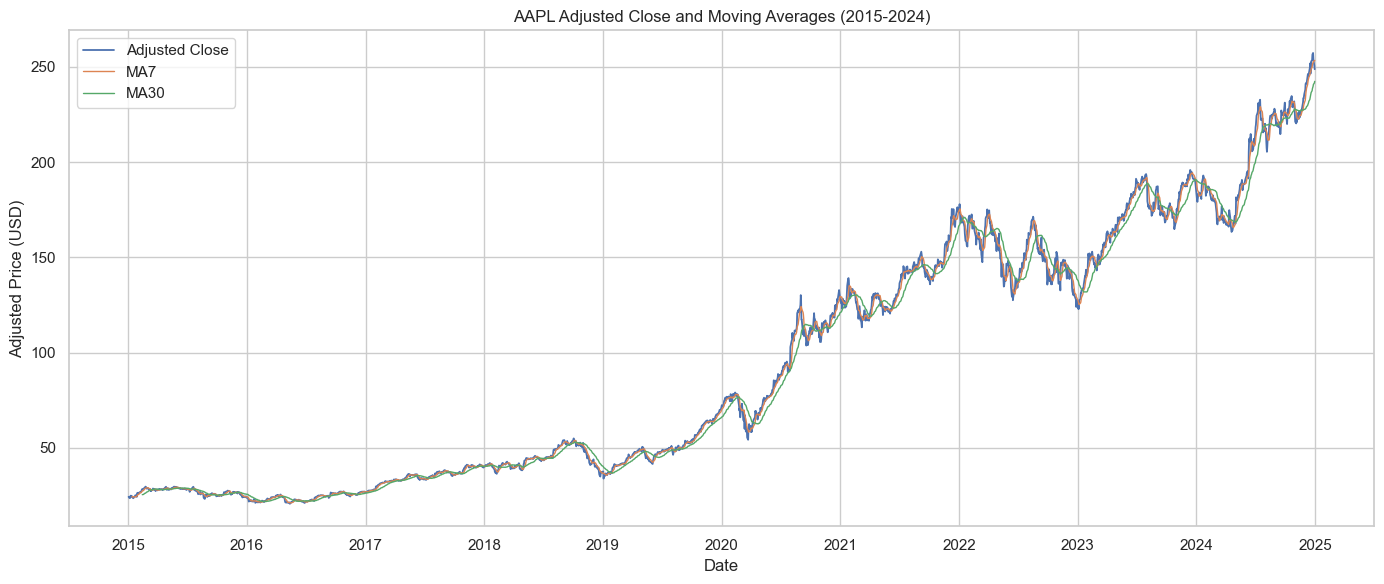

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"], label="Adjusted Close", linewidth=1.3)
plt.plot(df["Date"], df["MA7"], label="MA7", linewidth=1.0)
plt.plot(df["Date"], df["MA30"], label="MA30", linewidth=1.0)
plt.title("AAPL Adjusted Close and Moving Averages (2015-2024)")
plt.xlabel("Date")
plt.ylabel("Adjusted Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

Daily-return IQR outliers: 135
Log-volume-change IQR outliers: 60
Largest absolute daily returns:


,Date,Close,Daily_Return
1279,2020-03-16,58.470352,-0.128647
1278,2020-03-13,67.102943,0.119809
1375,2020-07-31,102.883904,0.104689
1285,2020-03-24,59.597698,0.100325
978,2019-01-03,33.736988,-0.099607
1277,2020-03-12,59.923576,-0.098755
1269,2020-03-02,72.133789,0.093101
1950,2022-11-10,144.418900,0.088975
1294,2020-04-06,63.361195,0.087237
1399,2020-09-03,117.250427,-0.080061


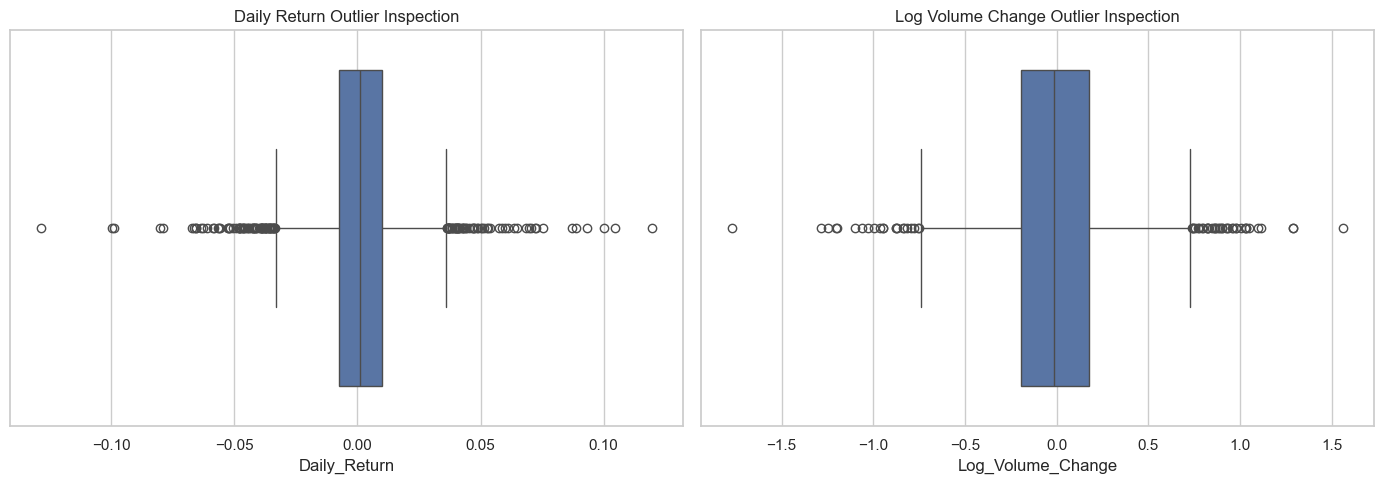

In [6]:
def iqr_outlier_mask(series: pd.Series) -> pd.Series:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

return_outliers = iqr_outlier_mask(model_df["Daily_Return"])
volume_outliers = iqr_outlier_mask(model_df["Log_Volume_Change"])

print("Daily-return IQR outliers:", int(return_outliers.sum()))
print("Log-volume-change IQR outliers:", int(volume_outliers.sum()))
print("Largest absolute daily returns:")
display(
    model_df.loc[:, ["Date", "Close", "Daily_Return"]]
    .assign(Absolute_Return=lambda x: x["Daily_Return"].abs())
    .nlargest(10, "Absolute_Return")
    .drop(columns="Absolute_Return")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=model_df["Daily_Return"], ax=axes[0])
axes[0].set_title("Daily Return Outlier Inspection")
sns.boxplot(x=model_df["Log_Volume_Change"], ax=axes[1])
axes[1].set_title("Log Volume Change Outlier Inspection")
plt.tight_layout()
plt.show()

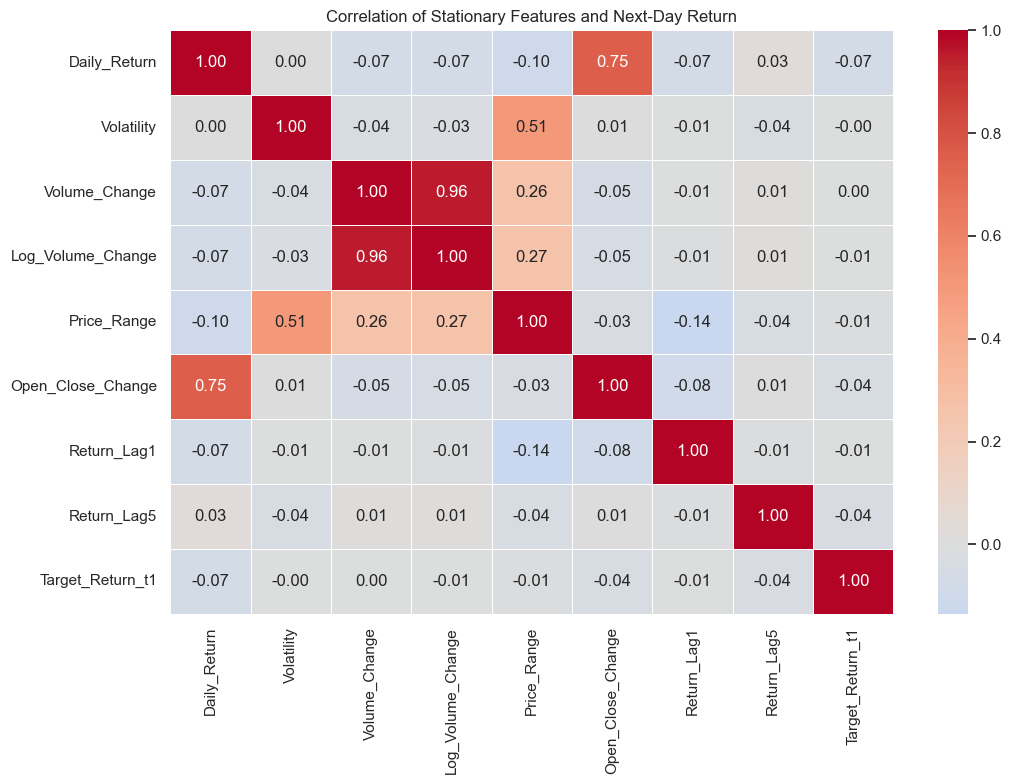

,Correlation_with_Target_Return_t1
Daily_Return,-0.069040
Open_Close_Change,-0.041603
Return_Lag5,-0.035248
Price_Range,-0.008312
Return_Lag1,-0.006148
Log_Volume_Change,-0.006008
Volatility,-0.003923
Volume_Change,0.001112


In [7]:
analysis_columns = [
    "Daily_Return", "Volatility", "Volume_Change", "Log_Volume_Change",
    "Price_Range", "Open_Close_Change", "Return_Lag1", "Return_Lag5",
    "Target_Return_t1",
]
corr_matrix = model_df[analysis_columns].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation of Stationary Features and Next-Day Return")
plt.tight_layout()
plt.show()

target_correlations = corr_matrix["Target_Return_t1"].drop("Target_Return_t1").sort_values()
display(target_correlations.to_frame("Correlation_with_Target_Return_t1"))

This correlation analysis uses returns, volatility, relative ranges, and lagged changes. It avoids interpreting the near-perfect correlation among trending price levels as evidence of predictive power.

In [8]:
descriptive_columns = [
    "Close", "Volume", "Daily_Return", "Volatility", "Log_Volume_Change",
    "Price_Range", "Open_Close_Change", "Target_Return_t1",
]
descriptive_stats = model_df[descriptive_columns].describe().T
descriptive_stats["median"] = model_df[descriptive_columns].median()
display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max,median
Close,2486.0,9.442120e+01,6.521689e+01,2.056586e+01,3.572013e+01,6.632906e+01,1.504996e+02,2.573755e+02,6.632906e+01
Volume,2486.0,1.155460e+08,6.659747e+07,2.323470e+07,7.065205e+07,9.914470e+07,1.406238e+08,6.488252e+08,9.914470e+07
Daily_Return,2486.0,1.040774e-03,1.789663e-02,-1.286470e-01,-7.328200e-03,9.469187e-04,1.009972e-02,1.198087e-01,9.469187e-04
Volatility,2486.0,1.625214e-02,7.647832e-03,4.815343e-03,1.122944e-02,1.466912e-02,1.911342e-02,6.800416e-02,1.466912e-02
Log_Volume_Change,2486.0,-8.550282e-04,3.075209e-01,-1.772503e+00,-1.925629e-01,-1.690362e-02,1.778836e-01,1.562764e+00,-1.690362e-02
Price_Range,2486.0,1.991729e-02,1.178465e-02,4.382079e-03,1.224617e-02,1.700258e-02,2.408313e-02,1.629170e-01,1.700258e-02
Open_Close_Change,2486.0,8.581277e-04,1.380802e-02,-7.257864e-02,-6.397705e-03,9.417764e-04,8.594738e-03,8.696110e-02,9.417764e-04
Target_Return_t1,2486.0,1.035963e-03,1.789719e-02,-1.286470e-01,-7.328200e-03,9.416615e-04,1.009972e-02,1.198087e-01,9.416615e-04


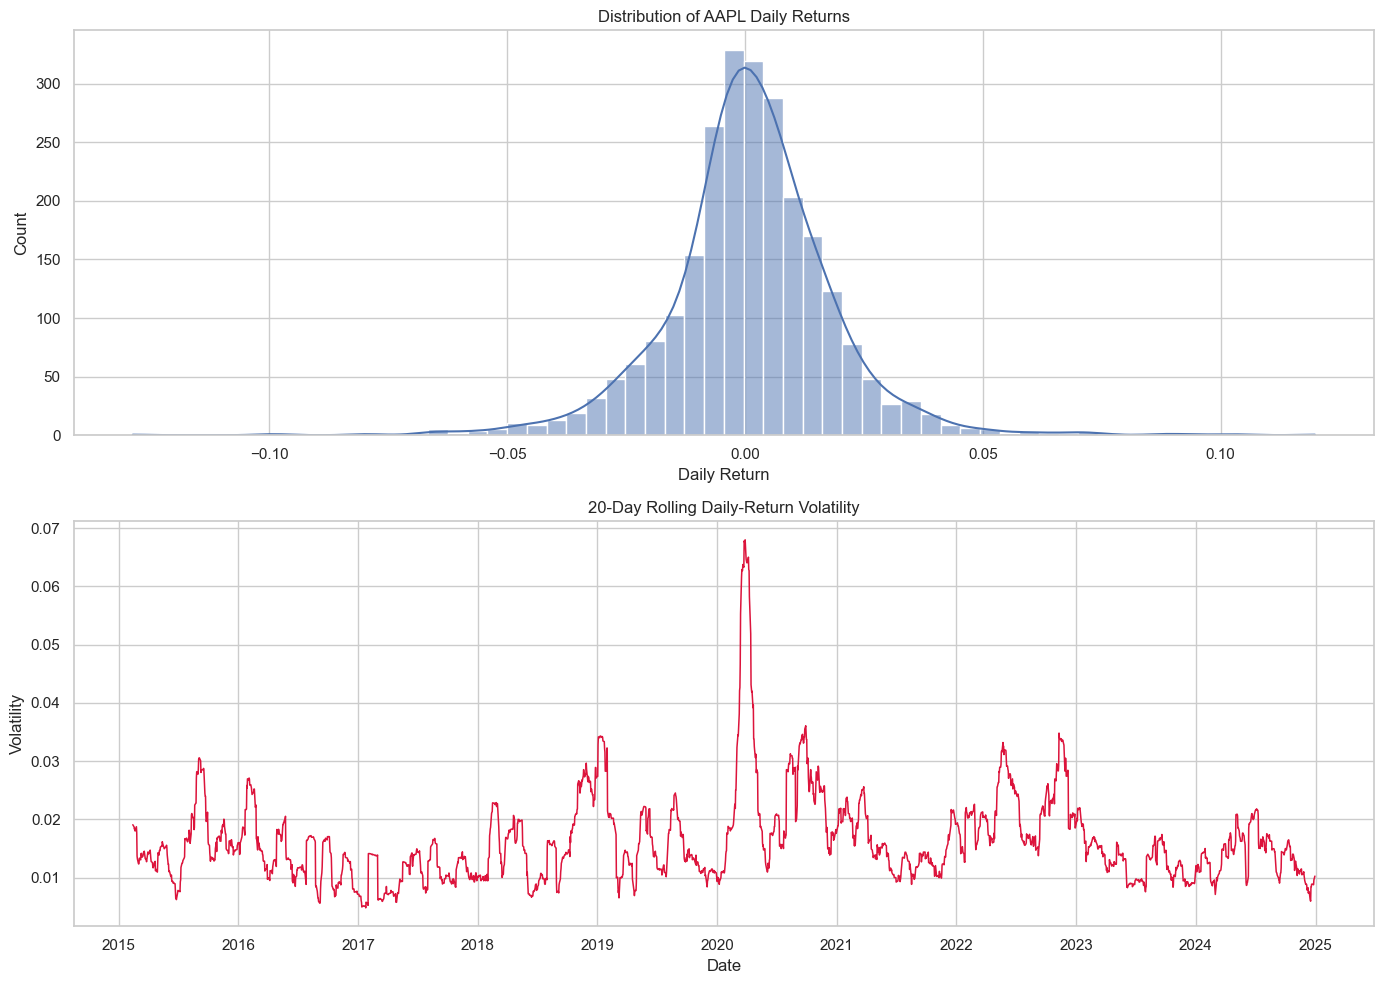

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
sns.histplot(model_df["Daily_Return"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Distribution of AAPL Daily Returns")
axes[0].set_xlabel("Daily Return")

axes[1].plot(model_df["Date"], model_df["Volatility"], color="crimson", linewidth=1.1)
axes[1].set_title("20-Day Rolling Daily-Return Volatility")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Volatility")
plt.tight_layout()
plt.show()

## 4. Chronological Split and Modeling Export

**Purpose of this section:** prepare the exact dataset used by model development.

The split is chronological: Train = 2015-2022, Validation = 2023, Test = 2024. This avoids random-split leakage in time-series data.


In [10]:
# Chronological split keeps future observations separate from fitting and tuning.
train_mask = model_df["Date"] < "2023-01-01"
validation_mask = (model_df["Date"] >= "2023-01-01") & (model_df["Date"] < "2024-01-01")
test_mask = model_df["Date"] >= "2024-01-01"

prepared_df = model_df.copy()
prepared_df["Split"] = np.select(
    [train_mask, validation_mask, test_mask],
    ["Train", "Validation", "Test"],
    default="Unassigned",
)

split_summary = (
    prepared_df.groupby("Split", sort=False)
    .agg(Rows=("Date", "size"), Start_Date=("Date", "min"), End_Date=("Date", "max"))
    .reset_index()
)
display(split_summary)

assert "Unassigned" not in prepared_df["Split"].unique()
assert prepared_df.loc[train_mask, "Date"].max() < prepared_df.loc[validation_mask, "Date"].min()
assert prepared_df.loc[validation_mask, "Date"].max() < prepared_df.loc[test_mask, "Date"].min()

prepared_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(prepared_df):,} rows to {OUTPUT_PATH}")


,Split,Rows,Start_Date,End_Date
0,Train,1985,2015-02-13,2022-12-30
1,Validation,250,2023-01-03,2023-12-29
2,Test,251,2024-01-02,2024-12-30


Saved 2,486 rows to AAPL_Prepared_for_Modeling.csv


In [11]:
# Persistence baseline: tomorrow's close is predicted as today's close.
test_df = prepared_df.loc[prepared_df["Split"] == "Test"].copy()
baseline_errors = test_df["Target_Close_t1"] - test_df["Close"]
baseline_mae = baseline_errors.abs().mean()
baseline_rmse = np.sqrt(np.mean(baseline_errors**2))
baseline_r2 = 1 - np.sum(baseline_errors**2) / np.sum(
    (test_df["Target_Close_t1"] - test_df["Target_Close_t1"].mean()) ** 2
)

baseline_results = pd.DataFrame(
    {"MAE": [baseline_mae], "RMSE": [baseline_rmse], "R2": [baseline_r2]},
    index=["Persistence baseline (Close_t)"],
)
display(baseline_results)
print("Every machine-learning model should be compared with this untouched 2024 baseline.")

,MAE,RMSE,R2
Persistence baseline (Close_t),2.104677,2.860591,0.98743


Every machine-learning model should be compared with this untouched 2024 baseline.


## EDA Summary and Modeling Rules

- The source dataset passed missing-value, duplicate-date, OHLC-validity, and positive-value checks.
- Rolling features use only information available by the end of day *t*. Warm-up rows are dropped rather than backfilled.
- The prediction target is explicitly aligned to the next trading day.
- Return-based outliers are retained because they represent observed market behavior; robust models or transformations can be considered later.
- Price-level correlations are dominated by common trends, so target-aware return correlations are used for interpretation.
- Model Development must use the provided chronological split. Hyperparameter tuning and `TimeSeriesSplit` cross-validation must operate on training data only; the 2024 test set remains untouched until final evaluation.
- Linear/Ridge Regression, Random Forest, and XGBoost should each be implemented in a pipeline and compared with the persistence baseline using MAE, MSE, RMSE, and R-squared.

Final check: this notebook produces the modeling CSV and records the rules that Member 3 uses in model development.
